In [3]:
!mamba install pandas numpy matplotlib seaborn scikit-learn

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn, scikit-learn
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 2.6063000000119207 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ brotli-python                 1.2.0                         py313h33caa6c_0               emscripten-forge              
+ certifi                       2026.4.22                     pyhd8ed1ab_0                  conda-forge                   
+ charset-normalizer            3.4.7                         pyhd8ed1ab_0                  conda-forge                   
+ idna                          3.13                          pyhcf101f3_0                  conda-forge                   
+ joblib                    

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so



In [5]:
df = pd.read_csv ('NYPD_Arrest_Data_(Year_to_Date)_20260504.csv')

In [6]:
df.head()

,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,KY_CD,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,PERP_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Location
0,318451126,01/06/2026,105.0,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,Q,110,0,25-44,M,BLACK,1020232,210719,40.744989,-73.870145,POINT (-73.870145 40.744989)
1,318308486,01/03/2026,203.0,"TRESPASS 3, CRIMINAL",352.0,CRIMINAL TRESPASS,PL 140100G,M,K,77,1,25-44,M,BLACK,1003358,182945,40.668798,-73.931120,POINT (-73.93112014 40.66879784)
2,318550123,01/08/2026,105.0,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,B,48,0,25-44,M,WHITE HISPANIC,1011780,246837,40.844152,-73.900500,POINT (-73.9005 40.844152)
3,318580867,01/07/2026,397.0,"ROBBERY,OPEN AREA UNCLASSIFIED",105.0,ROBBERY,PL 160102B,F,M,28,0,(null),(null),BLACK,999788,233328,40.807102,-73.943874,POINT (-73.943874 40.807102)
4,318684449,01/10/2026,397.0,"ROBBERY,OPEN AREA UNCLASSIFIED",105.0,ROBBERY,PL 160102A,F,B,45,0,<18,F,BLACK,1031351,254245,40.864401,-73.829711,POINT (-73.829711 40.864401)


In [57]:
df.groupby(['PERP_RACE']).count()

,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,KY_CD,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Location
PERP_RACE,,,,,,,,,,,,,,,,,,
AMERICAN INDIAN/ALASKAN NATIVE,204,204,204,204,204,204,204,202,204,204,204,204,204,204,204,204,204,204
ASIAN / PACIFIC ISLANDER,4096,4096,4096,4096,4096,4096,4096,4067,4096,4096,4096,4096,4096,4096,4096,4096,4096,4096
BLACK,33340,33340,33338,33340,33334,33340,33340,33259,33340,33340,33340,33340,33340,33340,33340,33340,33340,33340
BLACK HISPANIC,6651,6651,6651,6651,6650,6651,6651,6611,6651,6651,6651,6651,6651,6651,6651,6651,6651,6651
UNKNOWN,174,174,174,174,174,174,174,172,174,174,174,174,174,174,174,174,174,174
WHITE,7175,7175,7175,7175,7172,7175,7175,7141,7175,7175,7175,7175,7175,7175,7175,7175,7175,7175
WHITE HISPANIC,17665,17665,17665,17665,17663,17665,17665,17586,17665,17665,17665,17665,17665,17665,17665,17665,17665,17665


In [7]:
s_df=df[['OFNS_DESC','ARREST_BORO','AGE_GROUP','PERP_RACE']]

In [8]:
s_df.head()

,OFNS_DESC,ARREST_BORO,AGE_GROUP,PERP_RACE
0,FELONY ASSAULT,Q,25-44,BLACK
1,CRIMINAL TRESPASS,K,25-44,BLACK
2,FELONY ASSAULT,B,25-44,WHITE HISPANIC
3,ROBBERY,M,(null),BLACK
4,ROBBERY,B,<18,BLACK


In [9]:
s_df2=s_df[s_df['AGE_GROUP'] !='(null)']

In [58]:
s_df3=s_df2.groupby(['AGE_GROUP','ARREST_BORO','PERP_RACE'], as_index=False)['OFNS_DESC'].count()

In [66]:
s_df3=s_df3.rename(columns={'PERP_RACE':'RACE','OFNS_DESC':'COUNT_OF_OFNS'})

In [76]:
s_df3=s_df3[(s_df3['RACE'].str.contains('WHITE'))]

In [77]:
s_df3.head(10)

,AGE_GROUP,ARREST_BORO,RACE,COUNT_OF_OFNS
5,18-24,B,WHITE,26
6,18-24,B,WHITE HISPANIC,435
12,18-24,K,WHITE,162
13,18-24,K,WHITE HISPANIC,420
19,18-24,M,WHITE,117
20,18-24,M,WHITE HISPANIC,379
26,18-24,Q,WHITE,82
27,18-24,Q,WHITE HISPANIC,708
33,18-24,S,WHITE,53
34,18-24,S,WHITE HISPANIC,76


In [78]:
filter_A='B'
filter_B='S'

In [79]:
BX_df=s_df3[s_df3['ARREST_BORO'] ==filter_A]
SI_df=s_df3[s_df3['ARREST_BORO'] ==filter_B]


[Text(0.5, 1.0, 'Bronx Arrest by Race and Age')]

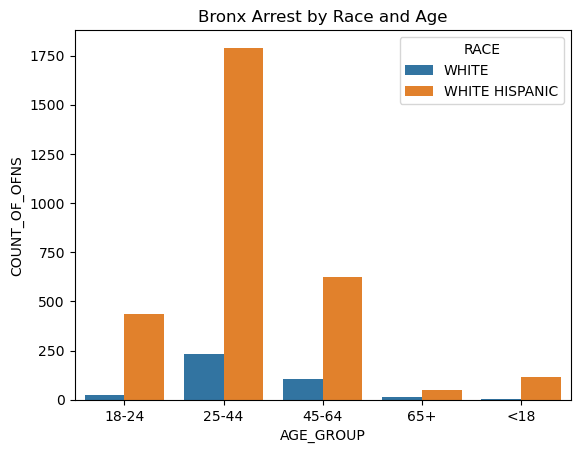

In [80]:
ax = sns.barplot(data=BX_df, y='COUNT_OF_OFNS',x='AGE_GROUP', hue='RACE') 
ax.set(title='Bronx Arrest by Race and Age')


[Text(0.5, 1.0, 'Staten Island Arrest by Race and Age')]

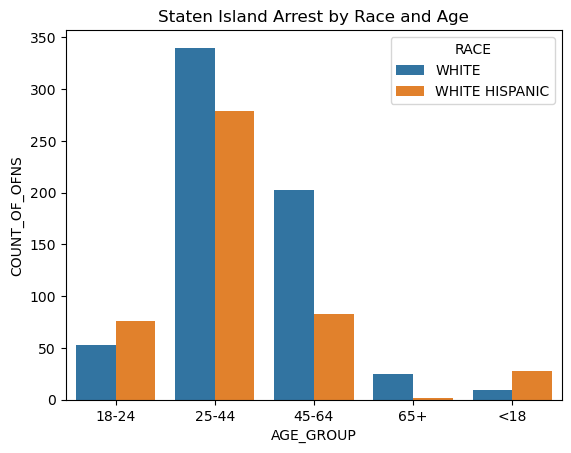

In [81]:
ax = sns.barplot(data=SI_df, y='COUNT_OF_OFNS',x='AGE_GROUP', hue='RACE')
ax.set(title='Staten Island Arrest by Race and Age')

Based on the NYPD arrest data I compared Whites and White Hispanics in Bronx and Staten Island. From what I noticed in the counts, arrest based on race and Age group varies based on Geographic location. The Bronx reflects discrepancy between Whites and White Hispanics. This may be due to a larger population of Hispanics in the Bronx. When looking at the data from Staten Island we see that the Discrepancy is towards Whites. This might be due to the borough having  higher population of Whites than in the Bronx.